In [2]:
from datetime import datetime, timedelta, time
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pm4py
import os

c:\Users\nikla\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


### Question 1: Initial Overview

### Load data

In [3]:
# Load the event log
file_path = os.path.join(os.getcwd(), 'Event Logs', 'all.xes')
log = pm4py.read_xes(file_path)
df = pm4py.convert_to_dataframe(log)

c:\Users\nikla\anaconda3\Lib\site-packages\pm4py\utils.py:1000: UserWarning: Install the optional requirement `rustxes` to import/export files faster.
  warnings.warn(


parsing log, completed traces ::   0%|          | 0/1820 [00:00<?, ?it/s]

### (a)

In [4]:
# (a) Quick check of the basics
n_cases = df['case:concept:name'].nunique()
n_events = len(df)
n_activities = df['concept:name'].nunique()

# Timeframe Calculation
earliest_event = df['time:timestamp'].min()
latest_event = df['time:timestamp'].max()
total_timeframe = latest_event - earliest_event

print(f"--- General Statistics ---")
print(f"Number of Cases:      {n_cases}")
print(f"Number of Events:     {n_events}")
print(f"Unique Activities:    {n_activities}")
print(f"\n--- Timeframe ---")
print(f"Earliest Event:       {earliest_event}")
print(f"Latest Event:         {latest_event}")
print(f"Total Duration:       {total_timeframe}")

--- General Statistics ---
Number of Cases:      1820
Number of Events:     47553
Unique Activities:    26

--- Timeframe ---
Earliest Event:       2021-01-01 00:00:01+00:00
Latest Event:         2023-09-13 09:00:03+00:00
Total Duration:       985 days 09:00:02


### (b)

In [5]:
#number of variants
variants = pm4py.get_variants(df)
num_variants = len(variants)

# average events per case

avg_events_per_case = n_events / n_cases

print(f"Number of Variants: {num_variants}")
print("Average Events per Case:",round(avg_events_per_case,2),)


Number of Variants: 678
Average Events per Case: 26.13


### (c)

In [6]:
# (c) Attribute Analysis and Mapping

# Identify all columns
all_cols = df.columns

# Case attributes usually start with 'case:'
case_attrs = [col for col in all_cols if col.startswith('case:')]

# Event attributes are the rest, excluding the standard activity and timestamp columns
standard_cols = ['concept:name', 'time:timestamp', 'case:concept:name']
event_attrs = [col for col in all_cols if col not in case_attrs and col not in standard_cols]

print("### Case Attributes ###")
for attr in case_attrs:
    print(f"- {attr}")

print("\n### Event Attributes and their Activities ###")
for attr in event_attrs:
    # Get unique activities where this attribute is not null
    activities_with_attr = df[df[attr].notna()]['concept:name'].unique()
    
    # Format the output for readability
    act_list = ", ".join(activities_with_attr)
    print(f"Attribute: '{attr}'")
    print(f"  -> Found in activities: {act_list}\n")

### Case Attributes ###
- case:concept:name
- case:customer_id
- case:customer_name
- case:customer_ssid
- case:loan_amount
- case:case_creation_no

### Event Attributes and their Activities ###
Attribute: 'org:resource'
  -> Found in activities: Application Registered, Retrieve Identity Document, Retrieve Internal Log Data, Verify ID Automatically, Confirmed Identity, Query Central Bank System, Query Credit Bureau, Retrieve Customer Global Risk Score, Retrieve Financial Status, Reject Application, Send Rejection Notification, Create Assessment Report, Verify ID Manually, Decide Loan Application, Send Acceptance Confirmation, Accept Terms, Received Terms Acceptance, Transfer Funds, Start Repayments, Loan Default Notice Received, Formally Initiate Debt Recovery, Send to Collections, Installment Received, Request to Defer Payment Received, Accelerate Loan (Force Default), Repayment Completed

Attribute: 'lifecycle:transition'
  -> Found in activities: Application Registered, Retrieve Ide

### (d)

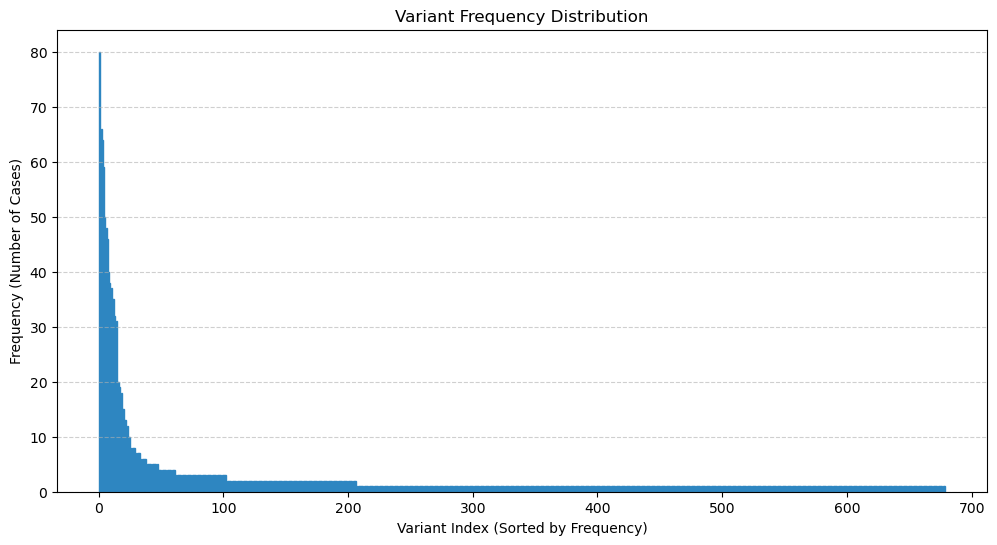

Total Cases: 1820
Total unique variants: 678
The most frequent variant covers 4.40% of all cases.


In [7]:
# 1. Get variants
variants = pm4py.get_variants(df)

# 2. Sort variants properly
# We check if the value is an integer (count) or a list (cases)
first_value = next(iter(variants.values()))

if isinstance(first_value, int):
    # If it's already a count, just use the value directly
    variants_sorted = sorted(variants.items(), key=lambda x: x[1], reverse=True)
    counts = [v[1] for v in variants_sorted]
else:
    # If it's a list of cases, take the length
    variants_sorted = sorted(variants.items(), key=lambda x: len(x[1]), reverse=True)
    counts = [len(v[1]) for v in variants_sorted]

# 3. Create the plot
variant_indices = range(1, len(counts) + 1)
plt.figure(figsize=(12, 6))
plt.bar(variant_indices, counts, color='#5DADE2', edgecolor='#2E86C1')
plt.xlabel('Variant Index (Sorted by Frequency)')
plt.ylabel('Frequency (Number of Cases)')
plt.title('Variant Frequency Distribution')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

# 4. Stats for insights
total_cases = sum(counts)
top_variant_perc = (counts[0] / total_cases) * 100
print(f"Total Cases: {total_cases}")
print(f"Total unique variants: {len(counts)}")
print(f"The most frequent variant covers {top_variant_perc:.2f}% of all cases.")

### (e)

--- Case Duration Statistics (in Days) ---
Minimum           : 0.2542
Maximum           : 758.4361
Mean              : 292.0517
Median            : 220.8598
Standard Deviation: 220.7629


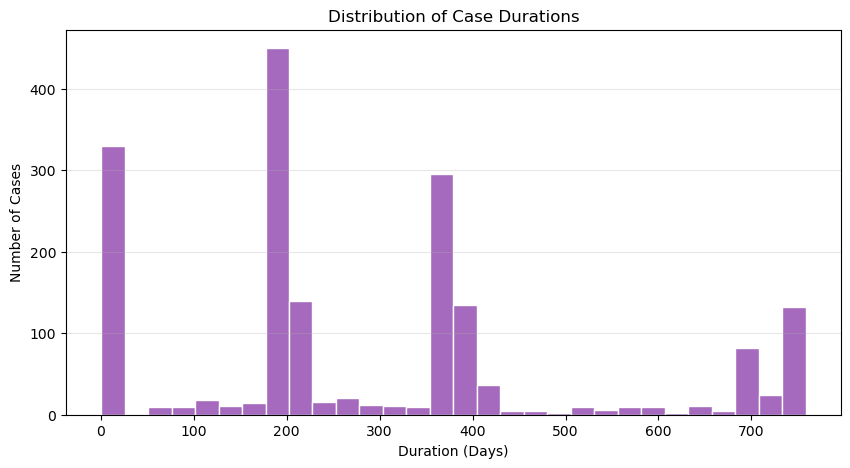

In [8]:
# 1. Calculate duration for each case
# We group by the case ID and find the difference between the max and min timestamp
case_durations = df.groupby('case:concept:name')['time:timestamp'].agg(lambda x: x.max() - x.min())

# 2. Convert durations to a numeric format (e.g., Days) for easier reporting
# Using total_seconds() / 86400 converts the timedeltas into a float representing days
durations_in_days = case_durations.dt.total_seconds() / 86400

# 3. Report Statistics
stats = {
    "Minimum": durations_in_days.min(),
    "Maximum": durations_in_days.max(),
    "Mean": durations_in_days.mean(),
    "Median": durations_in_days.median(),
    "Standard Deviation": durations_in_days.std()
}

print("--- Case Duration Statistics (in Days) ---")
for metric, value in stats.items():
    print(f"{metric:18}: {value:.4f}")

# 4. Optional: Quick histogram to visualize the distribution
plt.figure(figsize=(10, 5))
plt.hist(durations_in_days, bins=30, color='#A569BD', edgecolor='white')
plt.title('Distribution of Case Durations')
plt.xlabel('Duration (Days)')
plt.ylabel('Number of Cases')
plt.grid(axis='y', alpha=0.3)
plt.show()

### Question 2: General Visual Analytics & Exploration

### (a)

In [9]:
# select top 5 variants
variants_dict = pm4py.get_variants(df)
variants_sorted = sorted(variants_dict.items(), key=lambda x: (x[1] if isinstance(x[1], int) else len(x[1])), reverse=True)

# Select top 5
top_5 = variants_sorted[:5]

print("--- Top 5 Variants and Frequencies ---")
for i, (variant, count) in enumerate(top_5):
    # variant is a tuple of activity names
    print(f"Variant {i+1}: {' -> '.join(variant)}")
    print(f"Frequency: {count if isinstance(count, int) else len(count)}")
    print("-" * 30)

--- Top 5 Variants and Frequencies ---
Variant 1: Application Registered -> Retrieve Identity Document -> Retrieve Internal Log Data -> Verify ID Automatically -> Confirmed Identity -> Query Central Bank System -> Query Credit Bureau -> Retrieve Customer Global Risk Score -> Retrieve Financial Status -> Create Assessment Report -> Decide Loan Application -> Send Acceptance Confirmation -> Accept Terms -> Received Terms Acceptance -> Transfer Funds -> Start Repayments -> Installment Received -> Installment Received -> Installment Received -> Installment Received -> Installment Received -> Installment Received -> Repayment Completed
Frequency: 80
------------------------------
Variant 2: Application Registered -> Retrieve Identity Document -> Retrieve Internal Log Data -> Verify ID Automatically -> Confirmed Identity -> Query Central Bank System -> Retrieve Customer Global Risk Score -> Query Credit Bureau -> Retrieve Financial Status -> Create Assessment Report -> Decide Loan Applicatio

In [ ]:
# visualize top variant

# Filter the log to keep only cases belonging to the first variant
first_variant_tuple = top_5[0][0]
filtered_df = pm4py.filter_variants(df, [list(first_variant_tuple)])

# Discover the tree
process_tree = pm4py.discover_process_tree_inductive(filtered_df)

from pm4py.visualization.process_tree import visualizer as pt_visualizer

# Generate the visualization object
gviz = pt_visualizer.apply(process_tree)

# This line forces it to display inside the Jupyter Notebook
pt_visualizer.view(gviz)
filtered_df.head()

### Question 3: Use Case-Specific Visual Analytics & Exploration

### Question 4: Process Discovery

### Question 5: Conformance Checking